In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import datetime

C:\Users\zxzx2\Anaconda3\lib\site-packages\pandas\compat\_optional.py:138: UserWarning: Pandas requires version '2.7.0' or newer of 'numexpr' (version '2.6.9' currently installed).
  warnings.warn(msg, UserWarning)


In [2]:
pd.set_option('display.max_rows', 99999)
pd.set_option('display.max_columns', 500)
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('epc_best20.csv')
df.shape

(54495, 22)

In [4]:
df.head()

,Unnamed: 0,Total floor area (m²),Total current energy costs over 3 years (£),Current hot water costs over 3 years (£),Part 1 Construction Age Band,Part 1 Floor 0 Room Height,Low Energy Lighting %,Mechanical Ventilation,Tenure,Transaction Type,wall_insulation,roof_insulation,insulated_wall,wall_type,roof_type,floor_type,windows_glazing,MMH_mains gas,MHCS_programmer,low_lighting,SH_room heaters,Current energy efficiency rating band
0,0,45.0,3771.0,1176.0,before 1919,3.10,100,natural,owner-occupied,none of the above,no insulation,150 mm loft insulation,0,sandstone or limestone,Pitched,Unknown,double glazed,False,True,low energy lighting 100% of fixed outlets,False,E
1,1,143.0,2793.0,375.0,2003-2007,2.40,100,natural,owner-occupied,marketed sale,filled cavity,250 mm loft insulation,1,cavity wall,Pitched,Suspended,double glazed,True,True,low energy lighting 100% of fixed outlets,False,C
2,2,65.0,1947.0,441.0,before 1919,2.45,100,natural,owner-occupied,marketed sale,no insulation,300 mm loft insulation,0,sandstone or limestone,Unknown,Solid,single glazed,True,True,low energy lighting 100% of fixed outlets,False,C
3,3,49.0,1158.0,195.0,1999-2002,2.40,100,natural,rented (private),none of the above,insulated,300 mm loft insulation,1,cavity wall,Unknown,Suspended,double glazed,True,True,low energy lighting 100% of fixed outlets,False,C
4,4,212.0,6477.0,819.0,before 1919,2.80,64,natural,owner-occupied,marketed sale,with internal insulation,270 mm loft insulation,1,granite or whinstone,Pitched,Solid,double glazed,False,True,low energy lighting 60% of fixed outlets,True,E


In [5]:
objList = df.select_dtypes(include = "object").columns
# Label Encoding for object to numeric conversion
epc_encoded = df.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for feat in objList:
    epc_encoded[feat] = le.fit_transform(df[feat].astype(str))

epc_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54495 entries, 0 to 54494
Data columns (total 22 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Unnamed: 0                                   54495 non-null  int64  
 1   Total floor area (m²)                        54495 non-null  float64
 2   Total current energy costs over 3 years (£)  54495 non-null  float64
 3   Current hot water costs over 3 years (£)     54495 non-null  float64
 4   Part 1 Construction Age Band                 54495 non-null  int32  
 5   Part 1 Floor 0 Room Height                   54495 non-null  float64
 6   Low Energy Lighting %                        54495 non-null  int64  
 7   Mechanical Ventilation                       54495 non-null  int32  
 8   Tenure                                       54495 non-null  int32  
 9   Transaction Type                             54495 non-null  int32  
 10

In [6]:
epc_encoded.head()

,Unnamed: 0,Total floor area (m²),Total current energy costs over 3 years (£),Current hot water costs over 3 years (£),Part 1 Construction Age Band,Part 1 Floor 0 Room Height,Low Energy Lighting %,Mechanical Ventilation,Tenure,Transaction Type,wall_insulation,roof_insulation,insulated_wall,wall_type,roof_type,floor_type,windows_glazing,MMH_mains gas,MHCS_programmer,low_lighting,SH_room heaters,Current energy efficiency rating band
0,0,45.0,3771.0,1176.0,10,3.10,100,2,0,7,4,3,0,5,1,4,0,False,True,2,False,4
1,1,143.0,2793.0,375.0,8,2.40,100,2,0,4,0,6,1,1,1,1,0,True,True,2,False,2
2,2,65.0,1947.0,441.0,10,2.45,100,2,0,4,4,8,0,5,4,0,4,True,True,2,False,2
3,3,49.0,1158.0,195.0,7,2.40,100,2,1,7,3,8,1,1,4,1,0,True,True,2,False,2
4,4,212.0,6477.0,819.0,10,2.80,64,2,0,4,8,7,1,3,1,0,0,False,True,7,True,4


In [7]:
from sklearn.preprocessing import LabelEncoder
# Split data into features and labels
X = epc_encoded.drop("Current energy efficiency rating band", axis=1)
y = epc_encoded["Current energy efficiency rating band"]

In [8]:
from sklearn.model_selection import train_test_split
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [9]:
def plot_conf_mat(y_test, y_pred):
    '''prints the confusion matrix'''
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(5,5))
    ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.8)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(x=j, y=i,s=cm[i, j], va='center', ha='center', size='small')

    plt.xlabel('Predictions', fontsize=10)
    plt.ylabel('Actuals', fontsize=10)
    plt.title('Confusion Matrix', fontsize=10)
    plt.show()
    return

In [10]:
#libraries we need
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier
from sklearn.metrics import mean_squared_error
import time
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
import sklearn.metrics as metrics

DecisionTreeClassifier()
              precision    recall  f1-score   support

           0       0.46      0.49      0.48       198
           1       0.85      0.86      0.85      2627
           2       0.89      0.88      0.88      7281
           3       0.80      0.80      0.80      4266
           4       0.68      0.67      0.68      1414
           5       0.59      0.59      0.59       433
           6       0.62      0.69      0.66       130

    accuracy                           0.82     16349
   macro avg       0.70      0.71      0.70     16349
weighted avg       0.82      0.82      0.82     16349


r2: 0.49771635816487314

RMSE: 0.49771635816487314

Runtime of the model is 0.3389136791229248


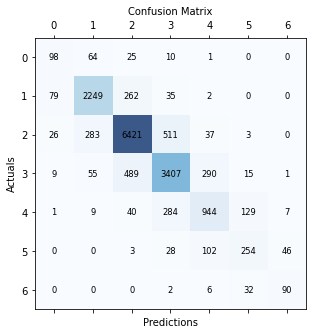



RandomForestClassifier()
              precision    recall  f1-score   support

           0       0.79      0.48      0.60       198
           1       0.93      0.87      0.90      2627
           2       0.90      0.92      0.91      7281
           3       0.80      0.84      0.82      4266
           4       0.71      0.67      0.69      1414
           5       0.63      0.54      0.58       433
           6       0.83      0.48      0.60       130

    accuracy                           0.85     16349
   macro avg       0.80      0.69      0.73     16349
weighted avg       0.85      0.85      0.85     16349


r2: 0.42152901284157984

RMSE: 0.42152901284157984

Runtime of the model is 5.263839244842529


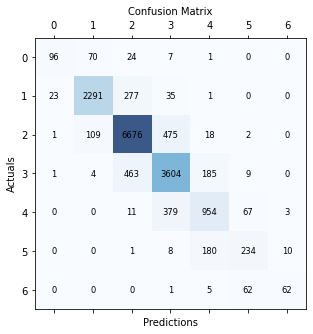



XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, objective='multi:softprob',
              predictor='auto', random_state=0, reg_alpha=0, ...)
              precision    recall  f1-score   support

           0       0.72      0.45      0.56       198
           1       0.93      0.89      0.91      2627
           2       0.93      0.93      0.93      7281
           3       0.84      0.88      0.86      4266
           4  

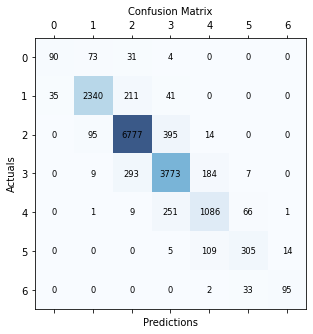



SVC(C=100.0)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       198
           1       0.81      0.75      0.77      2627
           2       0.77      0.87      0.81      7281
           3       0.66      0.65      0.65      4266
           4       0.51      0.42      0.46      1414
           5       0.43      0.23      0.30       433
           6       0.70      0.25      0.37       130

    accuracy                           0.72     16349
   macro avg       0.55      0.45      0.48     16349
weighted avg       0.70      0.72      0.71     16349


r2: 0.5790604702424811

RMSE: 0.5790604702424811

Runtime of the model is 109.61045026779175


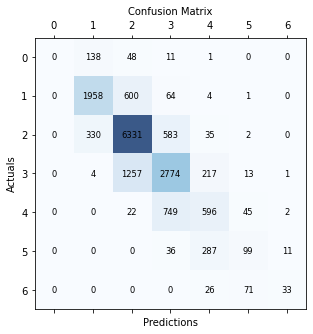

In [11]:
tree= DecisionTreeClassifier()
forest= RandomForestClassifier()
extra_tree= ExtraTreesClassifier()
knn= KNeighborsClassifier()
xboost= XGBClassifier()
abr = AdaBoostClassifier()
svc=SVC(C=100.0) 
gbc = GradientBoostingClassifier()
lg= LogisticRegression()
models= [
#     extra_tree, 
         tree, forest,xboost, svc ]
for model in models:
    start = time.time() #start time
    model.fit(X_train, y_train) # fit the model
    y_pred= model.predict(X_test) #  predict on the test set
    end = time.time() # end time
    #========metrics======#
    print(model)
    clf_report= classification_report(y_test, y_pred)  #with precision, recall and f1-score for each class
    print(clf_report)
    
    rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred)) 
    r2 = metrics.r2_score(y_test, y_pred)
    print(f"\nr2: {rmse}") ##print mean square error and r2
    print(f"\nRMSE: {rmse}")
    
    print(f"\nRuntime of the model is {end - start}") ##run time 
    plot_conf_mat(y_test, y_pred)
    print("\n")